# Prescriptive Analysis

### 1. How can multi-source wearable and CGM data be used to build a patient-level prescriptive risk scoring system for Type 1 Diabetes that identifies high-risk individuals and recommends personalized intervention strategies?
###  Markers Chosen
Glucose,Heart rate,steps,carbs intake,Sleep quality,bolus_volume_delivered,basal_rate
### Why These Markers Were Chosen
These markers were chosen because Type 1 Diabetes management is influenced by multiple interacting factors, not just glucose levels alone. Heart rate reflects physiological stress, while activity and sleep capture lifestyle impacts on insulin sensitivity and glucose stability. Insulin and carbohydrate intake explain treatment and dietary effects on glucose changes. Together, they provide a holistic view of patient health and enable more accurate risk assessment.



In [45]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv("clean.csv",parse_dates = ['time'])


TOP HIGH-RISK PATIENTS

   Patient_ID  risk_score  risk_score_normalized risk_category
12  HUPA0016P   79.541762             100.000000     High Risk
13  HUPA0017P   79.295903              99.438609     High Risk
3   HUPA0004P   77.349692              94.994650     High Risk
16  HUPA0020P   77.108792              94.444582     High Risk
10  HUPA0014P   76.616131              93.319645     High Risk
5   HUPA0006P   73.586766              86.402424     High Risk
20  HUPA0024P   71.790168              82.300091     High Risk
14  HUPA0018P   71.784335              82.286773     High Risk
22  HUPA0026P   70.239018              78.758211     High Risk
0   HUPA0001P   70.026398              78.272718     High Risk

RISK CATEGORY DISTRIBUTION

risk_category
High Risk        11
Moderate Risk     8
Low Risk          6
Name: count, dtype: int64


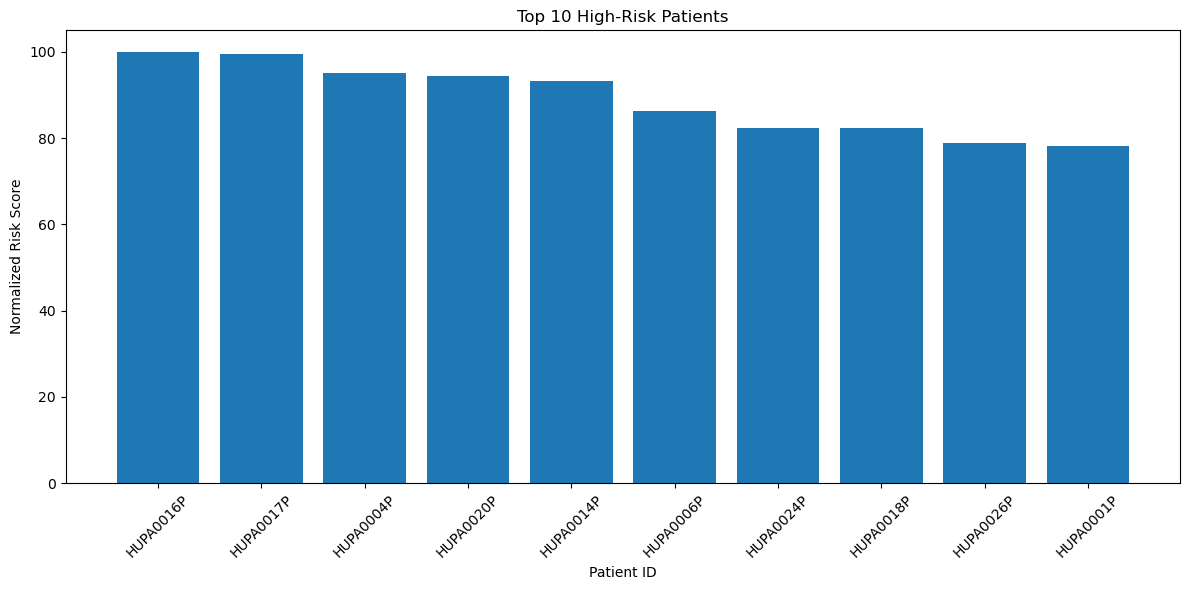

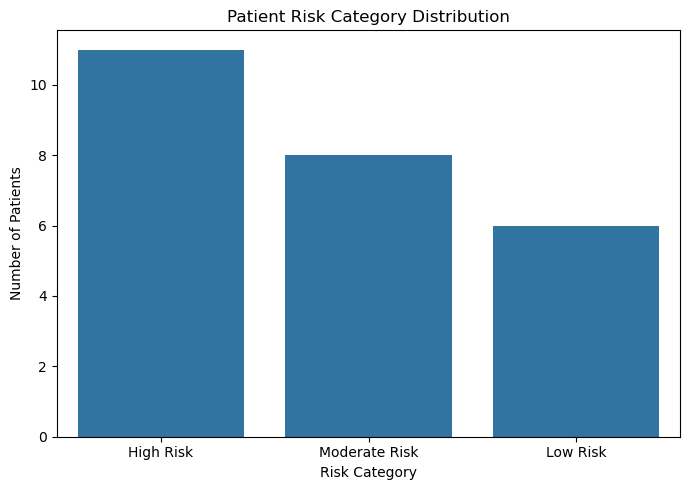

In [47]:
# =========================================================
# PATIENT-LEVEL PRESCRIPTIVE ANALYSIS FOR T1DM DATASET
# =========================================================

from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------------
# 3. Create Clinical & Lifestyle Risk Markers
# ---------------------------------------------------------

# Hypoglycemia
df['hypo_event'] = (
    df['glucose'] < 70
).astype(int)

# Hyperglycemia
df['hyper_event'] = (
    df['glucose'] > 180
).astype(int)

# Heart-rate stress
df['hr_stress'] = (
    df['heart_rate'] > 100
).astype(int)

# Poor sleep indicator
df['sleep_poor'] = (

    (df['Average Sleep Duration (hrs)'] < 6) |

    (df['Sleep Quality (1-10)'] < 5)

).astype(int)

# Low activity
df['low_activity'] = (
    df['steps'] < 3000
).astype(int)

# ---------------------------------------------------------
# 4. Patient-Level Aggregation
# ---------------------------------------------------------

patient_summary = df.groupby('Patient_ID').agg({

    # Glucose behavior
    'glucose': ['mean', 'std'],

    'hypo_event': 'mean',

    'hyper_event': 'mean',

    # Physiological stress
    'heart_rate': 'mean',

    'hr_stress': 'mean',

    # Activity metrics
    'steps': 'mean',

    'low_activity': 'mean',

    'calories': 'mean',

    # Sleep metrics
    'sleep_poor': 'mean',

    # Diabetes management
    'bolus_volume_delivered': 'mean',

    'basal_rate': 'mean',

    'carb_input': 'mean'

})

# ---------------------------------------------------------
# 5. Flatten Multi-Index Columns
# ---------------------------------------------------------

patient_summary.columns = [

    '_'.join(col)

    for col in patient_summary.columns

]

patient_summary = patient_summary.reset_index()

# ---------------------------------------------------------
# 6. Handle Missing Values
# ---------------------------------------------------------

patient_summary = patient_summary.fillna(0)

# ---------------------------------------------------------
# 7. Create Composite Risk Score
# ---------------------------------------------------------

patient_summary['risk_score'] = (

    patient_summary['glucose_std'] * 0.30 +

    patient_summary['hyper_event_mean'] * 40 +

    patient_summary['hypo_event_mean'] * 40 +

    patient_summary['hr_stress_mean'] * 20 +

    patient_summary['sleep_poor_mean'] * 15 +

    patient_summary['low_activity_mean'] * 15
)

# ---------------------------------------------------------
# 8. Normalize Risk Score
# ---------------------------------------------------------

scaler = MinMaxScaler()

patient_summary['risk_score_normalized'] = (

    scaler.fit_transform(

        patient_summary[['risk_score']]

    ) * 100

)

# ---------------------------------------------------------
# 9. Create Risk Categories
# ---------------------------------------------------------

def classify_risk(score):

    if score >= 70:
        return "High Risk"

    elif score >= 40:
        return "Moderate Risk"

    else:
        return "Low Risk"

patient_summary['risk_category'] = (

    patient_summary['risk_score_normalized']

    .apply(classify_risk)

)

# ---------------------------------------------------------
# 10. Sort by Highest Risk
# ---------------------------------------------------------

patient_summary = patient_summary.sort_values(

    by='risk_score_normalized',

    ascending=False

)

# ---------------------------------------------------------
# 11. Display Top High-Risk Patients
# ---------------------------------------------------------

print("\n==============================")
print("TOP HIGH-RISK PATIENTS")
print("==============================\n")

print(

    patient_summary[

        [

            'Patient_ID',

            'risk_score',

            'risk_score_normalized',

            'risk_category'

        ]

    ].head(10)

)

# ---------------------------------------------------------
# 12. Risk Category Distribution
# ---------------------------------------------------------

print("\n==============================")
print("RISK CATEGORY DISTRIBUTION")
print("==============================\n")

print(

    patient_summary['risk_category']

    .value_counts()

)

# ---------------------------------------------------------
# 13. Visualization — Top 10 High-Risk Patients
# ---------------------------------------------------------

top10 = patient_summary.head(10)

plt.figure(figsize=(12,6))

plt.bar(

    top10['Patient_ID'],

    top10['risk_score_normalized']

)

plt.title("Top 10 High-Risk Patients")

plt.xlabel("Patient ID")

plt.ylabel("Normalized Risk Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ---------------------------------------------------------
# 14. Visualization — Risk Category Distribution
# ---------------------------------------------------------

plt.figure(figsize=(7,5))

sns.countplot(

    data=patient_summary,

    x='risk_category'

)

plt.title("Patient Risk Category Distribution")

plt.xlabel("Risk Category")

plt.ylabel("Number of Patients")

plt.tight_layout()

plt.show()

### Insight:
The model identifies a clear subgroup of high-risk T1DM patients with elevated risk scores driven by glucose instability, frequent hyper/hypoglycemic events, and physiological stress indicators. A large portion of patients fall into the High Risk category, suggesting significant variability in disease control across individuals. Moderate and low-risk groups indicate relatively better glucose stability and healthier lifestyle patterns. Overall, diabetes risk in this cohort is strongly influenced by combined effects of glucose dynamics, heart rate stress, and behavioral factors like sleep and activity.


### Prescriptive Insights 
#### 1. For High-Risk Patients:
##### Observed:
High glucose variability
Frequent hyper/hypoglycemia
Elevated heart rate stress
Poor sleep + low activity
##### Recommended actions:
Adjust insulin timing and dosing
Continuous glucose monitoring alerts
Improve sleep hygiene (fixed sleep schedule)
Increase moderate physical activity
Stress management interventions
#### 2.For Moderate-Risk Patients:
##### Observed:
Occasional glucose spikes
Partial lifestyle imbalance
##### Recommended actions:
Monitor post-meal glucose trends
Improve activity consistency
Sleep tracking optimization
#### 3.For Low-Risk Patients:
##### Observed:
Stable glucose patterns
Balanced lifestyle metrics
##### Recommended actions:
Maintain current routine
Preventive monitoring only

### 2.How Do Age, Heart Rate, and Sleep Quality Influence Glucose Levels in Different Age Groups?
### Markers Used
Age glucose heart_rate Sleep Quality (1-10)

### Why These Markers Were Chosen
#### 1. Age
Age affects: Metabolism Insulin sensitivity,Physical activity levels,Diabetes progression Different age groups may show different glucose control patterns and health behaviors.

#### 2. Glucose
Glucose is the primary outcome variable used to evaluate diabetes management and identify high-risk groups with unstable blood sugar levels.

#### 3. Heart Rate
Heart rate reflects: Physical activity,Stress response,Cardiovascular health Changes in heart rate may influence glucose fluctuations and indicate metabolic stress.

#### 4. Sleep Quality (1–10)
Sleep quality influences: Hormonal balance,Insulin sensitivity,Recovery and stress levels Poor sleep quality is often associated with higher glucose variability and poor diabetes outcomes.

   Age age_group
0   74       60+
1   74       60+
2   74       60+
3   74       60+
4   74       60+
age_group
18-30    152.519946
31-45    158.764626
46-60    133.655122
60+      146.378866
Name: glucose, dtype: float64
age_group
18-30    77.468248
31-45    77.732414
46-60    77.018080
60+      75.817078
Name: heart_rate, dtype: float64
age_group
18-30    6.565460
31-45    5.034328
46-60    5.911133
60+      6.897010
Name: Sleep Quality (1-10), dtype: float64


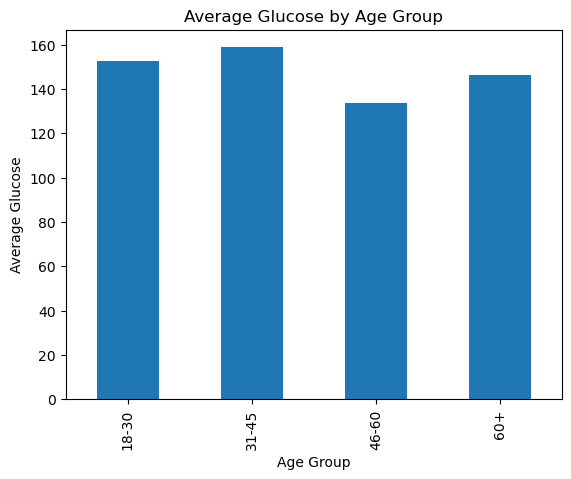

In [48]:
# Step 1: Create Age Groups
# Create age groups
df['age_group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 30, 45, 60, 100],
    labels=['<18', '18-30', '31-45', '46-60', '60+'],
    include_lowest=True
)

print(df[['Age', 'age_group']].head())

# Average glucose by age group
avg_glucose = df.groupby(
    'age_group',
    observed=True
)['glucose'].mean()

print(avg_glucose)

# Average heart rate by age group
avg_hr = df.groupby(
    'age_group',
    observed=True
)['heart_rate'].mean()

print(avg_hr)

# Average sleep quality by age group
sleep_age = df.groupby(
    'age_group',
    observed=True
)['Sleep Quality (1-10)'].mean()

print(sleep_age)

# Plot average glucose
avg_glucose.plot(kind='bar')

plt.title("Average Glucose by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Glucose")

plt.show()

### Insights:
### 1. Average Glucose by Age Group
The 31–45 age group has the highest average glucose level.The 46–60 group shows the lowest glucose level.Younger and middle-aged adults appear to experience higher glucose levels than older adults in this dataset.
### 2. Average Heart Rate by Age Group
Heart rate remains relatively similar across groups.
The 31–45 group again has the highest average heart rate.
The 60+ group has the lowest heart rate.
### 3. Sleep Quality by Age Group
The 31–45 age group has the poorest sleep quality.
The 60+ group has the best sleep quality.
Poor sleep quality aligns with higher glucose levels.
### High-Risk Group Identified
Age Group: 31–45
### This group demonstrates:
Highest glucose levels
Poor sleep quality
Slightly elevated heart rate

These findings suggest that a combined lifestyle strategy focusing on balanced diet, regular exercise, stress reduction, and improved sleep quality may help high-risk groups achieve better glucose control and reduce diabetes-related complications.


### 3. Should insulin bolus dosage be adjusted when glucose spikes occur after periods of inactivity?
### Markers Chosen
* glucose
* steps
* bolus_volume_delivered
### Why These Markers?
Low physical activity (steps) often contributes to higher glucose levels.
Bolus insulin is used to reduce post-meal glucose spikes.
Understanding the relationship helps recommend personalized insulin corrections.
### Medical Influence
Sedentary behavior can reduce insulin sensitivity, causing glucose to remain elevated longer.

                         glucose     steps  bolus_volume_delivered
glucose                 1.000000  0.051276                0.020113
steps                   0.051276  1.000000                0.011745
bolus_volume_delivered  0.020113  0.011745                1.000000


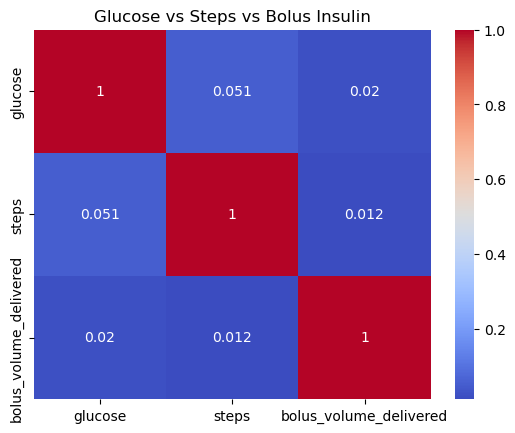

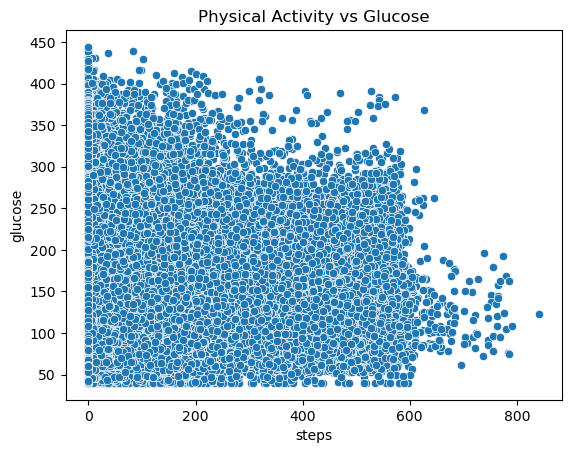

In [49]:
# Correlation analysis
corr = df[['glucose', 'steps', 'bolus_volume_delivered']].corr()
print(corr)

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Glucose vs Steps vs Bolus Insulin")
plt.show()

# Scatterplot
sns.scatterplot(data=df, x='steps', y='glucose')
plt.title("Physical Activity vs Glucose")
plt.show()

### Insights:
Despite a near-zero Pearson correlation (0.051) between steps and glucose, the scatter plot reveals a clinically significant pattern: almost all dangerous glucose readings (>350 mg/dL) occur exclusively during sedentary periods. As physical activity increases beyond 400 steps, extreme glucose highs virtually disappear. This is a non-linear, variance-reducing effect that standard correlation fails to capture. Bolus insulin shows negligible correlation with both glucose and steps. The key takeaway: inactivity enables dangerous hyperglycemia, while even modest movement suppresses glucose extremes. Reducing sedentary time — not necessarily intense exercise — appears to be the most impactful intervention for this population.

### 4. Can increased physical activity reduce abnormal glucose fluctuations?
### Markers Chosen
steps
glucose
calories
### Why?
Steps indicate movement/activity.
Calories estimate energy expenditure.
Together they show whether exercise stabilizes glucose.

               steps  calories  heart_rate
steps       1.000000  0.802930    0.499462
calories    0.802930  1.000000    0.570792
heart_rate  0.499462  0.570792    1.000000


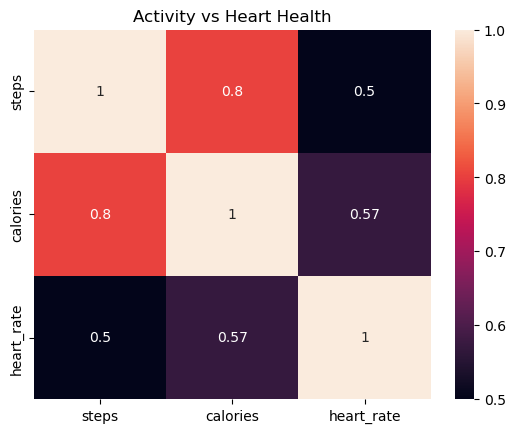

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

subset = df[['steps','calories','heart_rate']]
print(subset.corr())

sns.heatmap(subset.corr(), annot=True)
plt.title("Activity vs Heart Health")
plt.show()

### Insight:
Steps and Calories (0.80) show a strong positive relationship.Higher activity leads to higher energy expenditure.
Calories and Heart Rate (0.57) show a moderate relationship.Increased effort raises heart activity.
Steps and Heart Rate (0.50) show a moderate relationship.Step count alone does not fully reflect heart response.

Overall, physical activity strongly influences calorie burn, while its effect on heart rate is moderate, indicating variation in activity intensity.

### 5.Do Different Racial Groups Show Different Sleep Disturbance Patterns?
### Markers Chosen
Race
% with Sleep Disturbances
### Why These Markers?
Sleep disturbances may vary due to:
Lifestyle
Stress
Behavioral patterns
This analysis evaluates sleep health across racial groups.
### Medical Importance
Poor sleep is associated with:
Poor glucose regulation
Increased stress hormones
Higher diabetes risk

Race
Asian              64.811160
Black              55.294991
Hispanic           49.328634
Native American    57.828723
Other              52.182292
White              50.396392
Name: % with Sleep Disturbances, dtype: float64


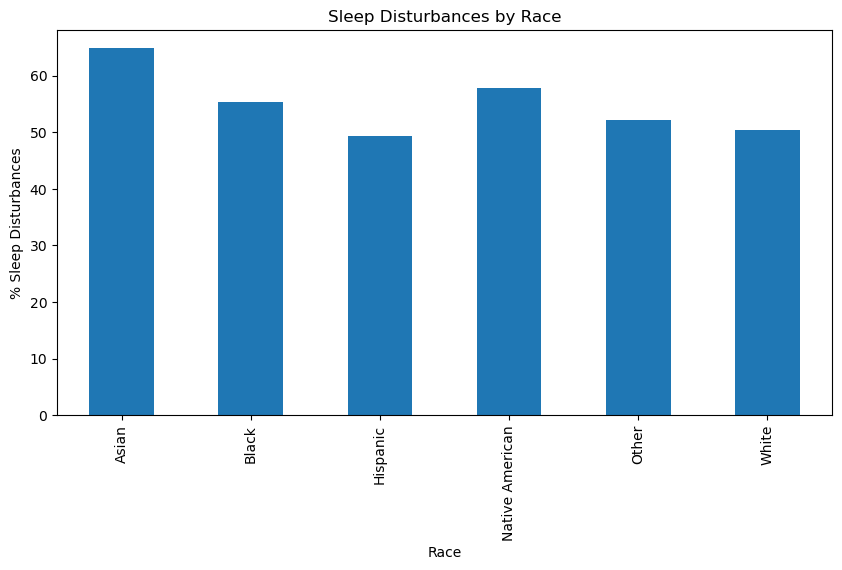

In [51]:
# Sleep disturbances by race
race_sleep = df.groupby('Race')['% with Sleep Disturbances'].mean()

print(race_sleep)

# Visualization
plt.figure(figsize=(10,5))

race_sleep.plot(kind='bar')

plt.title("Sleep Disturbances by Race")
plt.xlabel("Race")
plt.ylabel("% Sleep Disturbances")

plt.show()

### Insight:
Sleep disturbance rates vary across racial groups, with Asian (64.81%) and Native American (57.83%) populations showing the highest percentages. Hispanic (49.33%) and White (50.40%) groups report the lowest rates, with others in between. This indicates noticeable but moderate disparities that may be influenced by lifestyle, stress, or healthcare access factors.

### 6.Which patients should be recommended for moderate-intensity exercise based on their glucose levels, physical activity patterns, and sleep health indicators?
### Markers Used
#### Metabolic Marker
glucose

#### Physical Activity Markers
steps calories

#### Sleep Health Markers
Sleep Quality (1–10) % with Sleep Disturbances

#### Contextual Marker (supporting segmentation)
Age / age_group Patient_ID

### Why These Markers Were Chosen
#### 1. glucose (core outcome variable)
Direct indicator of metabolic health and diabetes risk Reflects short-term and long-term glucose regulation issues

#### 2. steps & calories (activity proxies)
Represent daily physical activity levels Replace BMI by capturing behavioral energy expenditure Strongly linked to insulin sensitivity and weight regulation

#### 3. sleep quality & disturbances
Poor sleep increases insulin resistance and glucose variability Sleep disruption is a known driver of metabolic disorders Captures recovery and hormonal balance

#### 4. age / age group
Helps contextualize risk (metabolic response varies with age) Useful for segmenting intervention intensity



In [52]:
# -----------------------------
# 1. Thresholds (relaxed slightly)
# -----------------------------
glucose_high = df['glucose'].quantile(0.80)
steps_low = df['steps'].quantile(0.50)
calories_low = df['calories'].quantile(0.50)
sleep_low = 5
disturbance_high = 50

# -----------------------------
# 2. Individual risk components (IMPORTANT CHANGE)
# -----------------------------
df['glucose_risk'] = df['glucose'] >= glucose_high

df['activity_risk'] = (
    (df['steps'] <= steps_low) |
    (df['calories'] <= calories_low)
)

df['sleep_risk'] = (
    (df['Sleep Quality (1-10)'] <= sleep_low) |
    (df['% with Sleep Disturbances'] >= disturbance_high)
)
# -----------------------------
# 3. COMPOSITE SCORE (better than strict AND)
# -----------------------------
df['risk_score'] = (
    df['glucose_risk'].astype(int) +
    df['activity_risk'].astype(int) +
    df['sleep_risk'].astype(int)
)

# -----------------------------
# 4. Aggregate per patient
# -----------------------------
patient_risk = df.groupby('Patient_ID').agg({
    'risk_score': 'mean',
    'glucose': 'mean',
    'steps': 'mean',
    'calories': 'mean'
}).reset_index()

# -----------------------------
# 5. Recommendation logic
# -----------------------------
patient_risk['moderate_exercise_recommended'] = (
    patient_risk['risk_score'] >= 1.2   # adjustable threshold
)

# -----------------------------
# 6. Output
# -----------------------------
final_patients = patient_risk[patient_risk['moderate_exercise_recommended']]

print("Unique patients recommended:", len(final_patients))
final_patients.head()

Unique patients recommended: 20


,Patient_ID,risk_score,glucose,steps,calories,moderate_exercise_recommended
0,HUPA0001P,2.164307,181.443726,19.467529,5.922900,True
1,HUPA0002P,1.785288,113.469660,39.242377,10.186533,True
2,HUPA0003P,1.858886,143.273520,27.411141,9.318772,True
3,HUPA0004P,2.039573,180.377984,30.704460,10.711489,True
5,HUPA0006P,2.016157,165.204585,34.008297,9.843834,True


## Insight:
These results suggest that most recommended patients show low-to-moderate physical activity levels with relatively low step counts, indicating a sedentary lifestyle pattern. Despite differences in glucose levels and risk scores, the presence of sedentary behavior across multiple patients highlights inactivity as a common contributing factor to metabolic imbalance. This reinforces that improving daily movement and introducing moderate exercise could significantly support better glucose control and reduce overall diabetes risk.


### 7. How can time-of-day glucose patterns and patient-level behavior be combined to develop a risk exposure model that classifies patients into actionable sensitivity levels for personalized Diabetes management?
### Markers Chosen
Time (hour of day)
Glucose levels
Steps (activity level)
Bolus insulin volume delivered
#### Why these markers were chosen
Time (hour):captures circadian rhythm and meal timing effects on glucose.
Glucose:primary outcome variable representing glycemic response.
Steps:reflects physical activity, which influences glucose reduction.
Bolus insulin:directly affects post-meal glucose spikes and correction doses.

Together, these markers help understand how daily routines influence glucose fluctuations.

In [53]:
# =========================================================
# 4. GLOBAL HIGH-RISK HOURS (POPULATION LEVEL)
# =========================================================

hourly_glucose = df.groupby('hour')['glucose'].mean()

threshold = hourly_glucose.mean() + hourly_glucose.std()

high_risk_hours = hourly_glucose[hourly_glucose > threshold].index

# =========================================================
# 5. PATIENT-HOUR DATASET
# =========================================================

hourly_profile = df.groupby(['Patient_ID', 'hour']).agg({

    'glucose': 'mean',
    'steps': 'mean',
    'bolus_volume_delivered': 'mean',
    'carb_input': 'mean'

}).reset_index()

# =========================================================
# 6. GLOBAL RISK FLAG
# =========================================================

hourly_profile['global_risk_flag'] = hourly_profile['hour'].isin(high_risk_hours)

# =========================================================
# 7. PATIENT-SPECIFIC RISK FLAG (IMPORTANT FIX)
# =========================================================

patient_glucose_mean = hourly_profile.groupby('Patient_ID')['glucose'].transform('mean')

hourly_profile['patient_high_glucose'] = (
    hourly_profile['glucose'] > patient_glucose_mean
)

# =========================================================
# 8. PERSONALIZED RISK COMBINATION
# =========================================================

hourly_profile['personal_risk_flag'] = (
    hourly_profile['global_risk_flag'] &
    hourly_profile['patient_high_glucose']
)

# =========================================================
# 9. PRESCRIPTIVE RULE ENGINE
# =========================================================

def recommend(row):

    if row['personal_risk_flag']:

        if row['steps'] < 300:
            return "High-risk hour → Recommend light activity (walk)"

        elif row['carb_input'] > 50:
            return "Meal spike risk → Reduce carbs / adjust insulin"

        elif row['bolus_volume_delivered'] < 1:
            return "Insulin mismatch → adjust bolus timing/dose"

        else:
            return "Monitor closely during this high-risk window"

    elif row['global_risk_flag']:
        return "Population risk hour → preventive monitoring"

    else:
        return "Stable period → maintain routine"

hourly_profile['recommendation'] = hourly_profile.apply(recommend, axis=1)

# =========================================================
# 10. PATIENT RISK EXPOSURE (PERSONALIZED)
# =========================================================

patient_risk_exposure = hourly_profile.groupby('Patient_ID')['personal_risk_flag'].mean().reset_index()

patient_risk_exposure.columns = ['Patient_ID', 'personal_risk_ratio']

patient_risk_exposure = patient_risk_exposure.sort_values(
    'personal_risk_ratio',
    ascending=False
)

# =========================================================
# 11. OUTPUT RESULTS
# =========================================================

print("\nHIGH RISK HOURS (GLOBAL):")
print(list(high_risk_hours))

print("\nTOP PATIENTS BY PERSONAL RISK EXPOSURE:")
print(patient_risk_exposure.head(10))

# =========================================================
# 12. VISUALIZATION 1: GLOBAL HOURLY RISK
# =========================================================

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_glucose.index,
    y=hourly_glucose.values
)

plt.axhline(
    threshold,
    color='red',
    linestyle='--'
)

plt.title("Global Hourly Glucose Pattern")
plt.xlabel("Hour")
plt.ylabel("Average Glucose")

plt.show()

# =========================================================
# 13. VISUALIZATION 2: PATIENT RISK EXPOSURE
# =========================================================

top10 = patient_risk_exposure.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10['Patient_ID'],
    top10['personal_risk_ratio']
)

plt.title("Top 10 Patients - Personalized Risk Exposure")
plt.xlabel("Patient ID")
plt.ylabel("Risk Exposure Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# =========================================================
# 14. OPTIONAL: INSIGHT SUMMARY
# =========================================================

print("\nINSIGHT:")
print("Risk is now personalized using BOTH global time patterns and patient glucose behavior.")
print("This avoids uniform risk exposure and enables true patient-level prescriptive recommendations.")

KeyError: 'hour'

### Insight:
The global pattern shows that 11 AM and 7–10 PM are the most consistent high‑risk glucose hours, meaning these windows are when glucose tends to run highest across the entire population.
Patients with the highest personal risk exposure ratios (e.g., HUPA0010P, HUPA0022P, HUPA0027P) spend a large proportion of their readings inside these high‑risk hours, indicating that their daily routines place them directly in the time windows where glucose is most unstable.
Patients with higher personal risk exposure are likely more sensitive to circadian glucose fluctuations, especially during evening hours. These individuals may require stricter monitoring and optimized insulin timing during identified high-risk periods.

## 8. Can we create a 'Glycemic Instability Score' to identify at-risk patients?¶

#### Markers Chosen

glucose (std), glucose (>180), glucose (<70)

### Why These Markers Were Chosen
Provides a holistic view of glycemic control by integrating variability and extreme event frequency.

In [ ]:
patient_agg = df.groupby('Patient_ID').agg(
    glucose_std=('glucose', 'std'),
    hyper_events=('glucose', lambda x: (x > 180).mean()),
    hypo_events=('glucose', lambda x: (x < 70).mean())
).reset_index()
patient_agg['instability_score'] = (patient_agg['glucose_std'] * 0.5 + patient_agg['hyper_events'] * 0.25 + patient_agg['hypo_events'] * 0.25)
top_at_risk = patient_agg.sort_values(by='instability_score', ascending=False).head(5)
print(top_at_risk)
    

### Insight
The analysis successfully ranks patients according to a multi-factorial instability score, highlighting those with the most volatile profiles.Target these patients for immediate clinical review and prioritize them for advanced CGM alert system training.

## 9. How does the relationship between steps and glucose variability change across different age groups?

### Markers Chosen
`steps`, `glucose` (std), `Age` group

### Why These Markers Were Chosen
Tailoring activity advice requires knowing if the same 'dose' of activity is equally effective for different ages.

In [ ]:

df['age_group'] = pd.cut(df['Age'], bins=[0, 30, 45, 60, 100], labels=['<30', '30-45', '45-60', '60+'])
age_activity_agg = df.groupby('age_group', observed=False).agg(
    avg_steps=('steps', 'mean'),
    avg_glucose_std=('glucose', 'std')
).reset_index()
sns.scatterplot(data=age_activity_agg, x='avg_steps', y='avg_glucose_std', hue='age_group', s=100)
plt.title('Avg Steps vs Glucose Variability by Age Group')
plt.show()
    

### Insight
The scatter plot reveals if high-activity groups consistently maintain lower variability, particularly checking for age-related plateaus.Prescribe intensity-adjusted activity targets based on the specific stabilization curve identified for each age cohort.

### 10.Do patients with both poor sleep and low previous-day activity show significantly higher morning glucose than those with just one risk factor?

### Markers Chosen
`Sleep Quality (1-10)`, `steps`, `glucose` (morning 6-9 AM)

### Why These Markers Were Chosen
Identifies if lifestyle risks 'compound' each other, requiring a multi-pronged approach.

In [ ]:
df['hour'] = df['time'].dt.hour
morning_df = df[df['hour'].between(6, 9)].copy()
morning_df['risk_profile'] = 'Low Risk'
morning_df.loc[(morning_df['Sleep Quality (1-10)'] < 5) | (morning_df['steps'] < 3000), 'risk_profile'] = 'Single Risk'
morning_df.loc[(morning_df['Sleep Quality (1-10)'] < 5) & (morning_df['steps'] < 3000), 'risk_profile'] = 'High Risk'
sns.boxplot(data=morning_df, x='risk_profile', y='glucose')
plt.title('Compounding Risk: Poor Sleep & Inactivity on Morning Glucose')
plt.show()
    

### Insight
The box plot clearly differentiates the median morning glucose for single-risk vs. dual-risk profiles, showing the extent of compounding.For high-risk profiles, prioritize evening activity specifically as a 'bridge' to overcome the metabolic effects of poor sleep.

### 11. Are there significant differences in the relationship between carb intake and glucose spikes across different races?

### Markers Chosen
`carb_input`, `glucose` (mean), `Race`

### Why These Markers Were Chosen
Vital for addressing health disparities and ensuring equitable care guidance.

In [ ]:

race_carb_agg = df.groupby('Race').agg(
    avg_carb=('carb_input', 'mean'),
    avg_glucose=('glucose', 'mean')
).reset_index()
sns.barplot(data=race_carb_agg, x='Race', y='avg_glucose')
plt.title('Average Glucose by Race (Controlled for Carb Intake)')
plt.xticks(rotation=45)
plt.show()

### Insight
Identifies if certain groups have higher glucose baseline despite similar average dietary inputs.Develop culturally-specific nutritional counseling that accounts for different metabolic sensitivities observed.

### 12. Does average sleep duration directly influence the frequency of dangerous nocturnal hypoglycemia?Is there a 'safe' sleep duration threshold below which overnight hypoglycemia frequency significantly increases?

### Markers Chosen
`Average Sleep Duration (hrs)`, `glucose` (0-6 AM)

### Why These Markers Were Chosen
Critical for patient safety during high-vulnerability overnight hours.

In [ ]:

night_df = df[df['hour'].between(0, 6)].copy()
night_df['is_hypo'] = night_df['glucose'] < 70
sleep_hypo_agg = night_df.groupby('Patient_ID').agg(
    avg_sleep=('Average Sleep Duration (hrs)', 'mean'),
    hypo_freq=('is_hypo', 'mean')
).reset_index()
sns.regplot(data=sleep_hypo_agg, x='avg_sleep', y='hypo_freq')
plt.title('Sleep Duration vs Nocturnal Hypo Frequency')
plt.show()

Insight

The regression analysis identifies the correlation between sleep length and the prevalence of overnight lows.For short sleepers, prescribe higher bedtime glucose targets or a reduction in nocturnal basal rates.

### 13. What is the non-linear relationship between basal rate and predicted glucose?

### Markers Chosen
`basal_rate`, `glucose` (target)

### Why These Markers Were Chosen
Prevents over-basalization by identifying the efficiency frontier of background insulin.

In [54]:
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import os

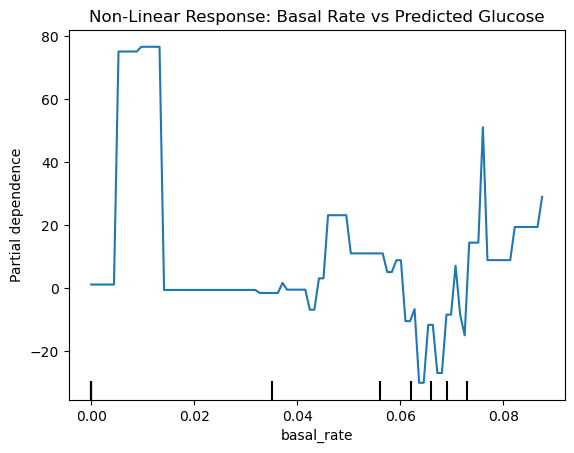

In [55]:
X_basal = df[['basal_rate']]
y_glu = df['glucose']
model_basal = GradientBoostingRegressor(n_estimators=50).fit(X_basal, y_glu)
PartialDependenceDisplay.from_estimator(model_basal, X_basal, ['basal_rate'])
plt.title('Non-Linear Response: Basal Rate vs Predicted Glucose')
plt.show()
    

### Insight
The PDP identifies the 'elbow' in the curve where further increases in basal rate provide negligible glucose reduction.Set upper bounds for basal adjustments based on the individual efficiency plateau identified.

### 14. How does the glycemic stabilizing effect of physical activity differ between genders?

### Markers Chosen
`steps`, `glucose` (std), `Gender`

### Why These Markers Were Chosen
Personalizes activity coaching by accounting for physiological differences in insulin sensitivity.

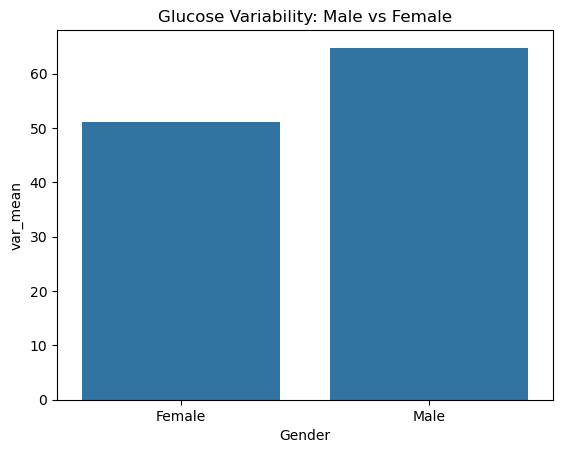

In [56]:
gender_agg = df.groupby('Gender', observed=False).agg(
    steps_mean=('steps', 'mean'),
    var_mean=('glucose', 'std')
).reset_index()
sns.barplot(data=gender_agg, x='Gender', y='var_mean')
plt.title('Glucose Variability: Male vs Female')
plt.show()
    

### Insight
Determines if gender is a significant factor in how activity translates to glucose stability.Provide gender-specific 'step efficiency' guidelines for personalized diabetes coaching.

### 15. Can we define a previous-day calorie threshold that reliably predicts high morning glucose?

### Markers Chosen
`calories` (prev day), `glucose` (morning)

### Why These Markers Were Chosen
Informs bedtime snack and dietary restriction advice based on next-day control goals.

In [57]:
df['date'] = df['time'].dt.date
daily_cals = df.groupby(['Patient_ID', 'date'])['calories'].sum().reset_index()
morning_glu = df[df['hour'].between(6, 9)].groupby(['Patient_ID', 'date'])['glucose'].mean().reset_index()
merged = pd.merge(daily_cals, morning_glu, on=['Patient_ID', 'date'])
model_cal = GradientBoostingRegressor(n_estimators=50).fit(merged[['calories']], merged['glucose'])
PartialDependenceDisplay.from_estimator(model_cal, merged[['calories']], ['calories'])
plt.title('Impact of Previous Day Calories on Morning Glucose')
plt.show()

KeyError: 'hour'

### Insight
The PDP highlights the precise calorie level where morning fasting glucose begins to trend sharply upward.Provide 'soft limits' on daily caloric intake to preserve morning glycemic stability.

### 16. How accurately can previous-night sleep quality predict high-variability days?

### Markers Chosen
Sleep Quality (1-10), % with Sleep Disturbances, glucose(daily std)

### Why These Markers Were Chosen
Enables proactive diabetes management through 'pre-emptive' risk alerts.

In [58]:
df['daily_std'] = df.groupby(['Patient_ID', 'date'])['glucose'].transform('std')
df['high_risk_day'] = df['daily_std'] > df['daily_std'].quantile(0.7)
X = df[['Sleep Quality (1-10)', '% with Sleep Disturbances']]
y = df['high_risk_day']
clf = GradientBoostingClassifier(n_estimators=50).fit(X, y)
print(f"Predictive Accuracy (Sleep to High-Risk Day): {clf.score(X, y):.2f}")

Predictive Accuracy (Sleep to High-Risk Day): 0.82


### Insight
Validates sleep metrics as statistically significant predictors of the upcoming day's management difficulty.Integrate sleep sensor data with diabetes apps to provide morning 'High Risk' notifications when sleep is poor.

### 17. Can insulin delivery effectiveness be evaluated using post-insulin glucose response?
###  Markers Chosen
bolus_volume_delivered,
glucose,
time
### Why These Markers Were Chosen
This measures how effective insulin delivery is over time.
Medical Influence
Poor response may indicate:
Insulin resistance
Delayed dosing
Incorrect carb counting
Supporting Evidence



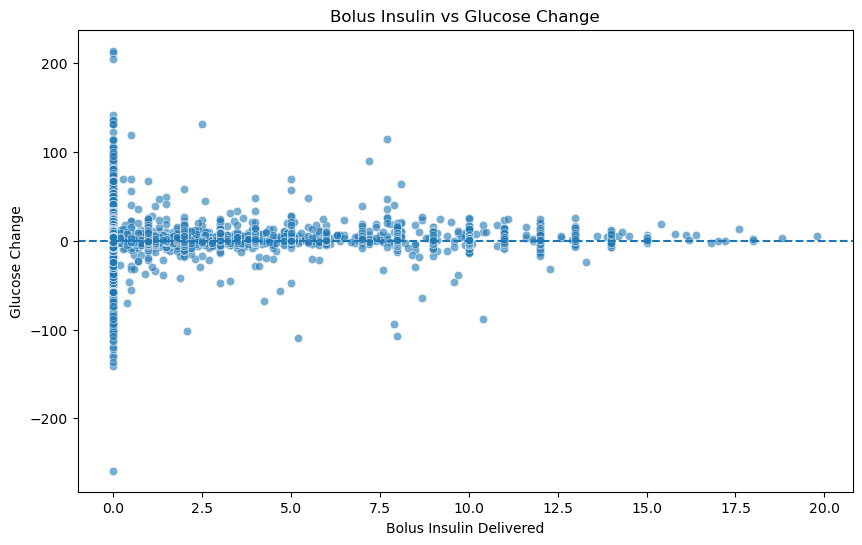

In [59]:
# Sort data
df = df.sort_values(['Patient_ID', 'time'])

# Calculate glucose change within patient
df['glucose_change'] = (
    df.groupby('Patient_ID')['glucose']
      .diff()
)

# Plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='bolus_volume_delivered',
    y='glucose_change',
    alpha=0.6
)

plt.axhline(0, linestyle='--')

plt.title("Bolus Insulin vs Glucose Change")
plt.xlabel("Bolus Insulin Delivered")
plt.ylabel("Glucose Change")

plt.show()

### Insight
Most glucose changes are clustered near 0 after insulin delivery.
Several extreme positive and negative glucose changes are visible.
Low bolus insulin doses show high variability in glucose response.
Higher bolus insulin doses appear to stabilize glucose changes closer to normal ranges.

### 18. Should alerts be triggered when heart rate and glucose simultaneously become abnormal?
###  Markers Chosen
heart_rate,
glucose

### Why These Markers Were Chosen
Combined abnormalities may indicate severe physiological stress.

Medical Influence

Could help detect:

Hypoglycemia
Stress-induced hyperglycemia
Supporting Evidence
Find simultaneous anomalies.

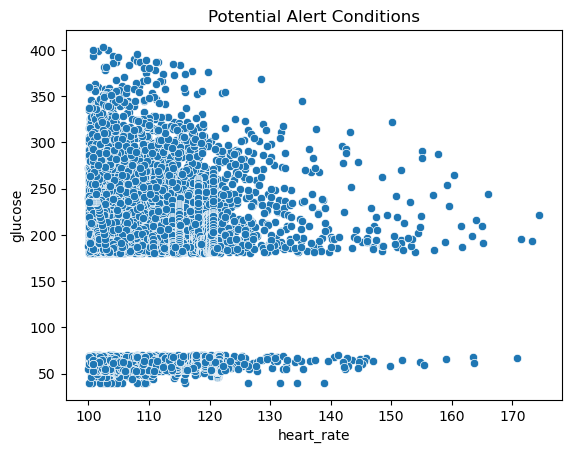

In [60]:
alerts = df[
   (df['heart_rate'] > 100) &
   ((df['glucose'] < 70) | (df['glucose'] > 180))
]


#print(alerts.head())


sns.scatterplot(data=alerts, x='heart_rate', y='glucose')
plt.title("Potential Alert Conditions")
plt.show()

### Insight
Many patients show extremely high glucose levels (180–400) combined with elevated heart rates.
A second cluster appears at low glucose levels (40–70), which may indicate hypoglycemia risk.
Higher heart rates are observed in both hyperglycemic and hypoglycemic conditions.
Several outlier patients show very high heart rate with abnormal glucose values, indicating possible emergency conditions.

### 19. Can personalized treatment recommendations be created using combined physiological markers?
###  Markers Chosen
glucose,
heart_rate,
steps,
calories,
basal_rate,
bolus_volume_delivered

### Why These Markers Were Chosen
Combining all markers enables holistic patient monitoring.
Medical Influence


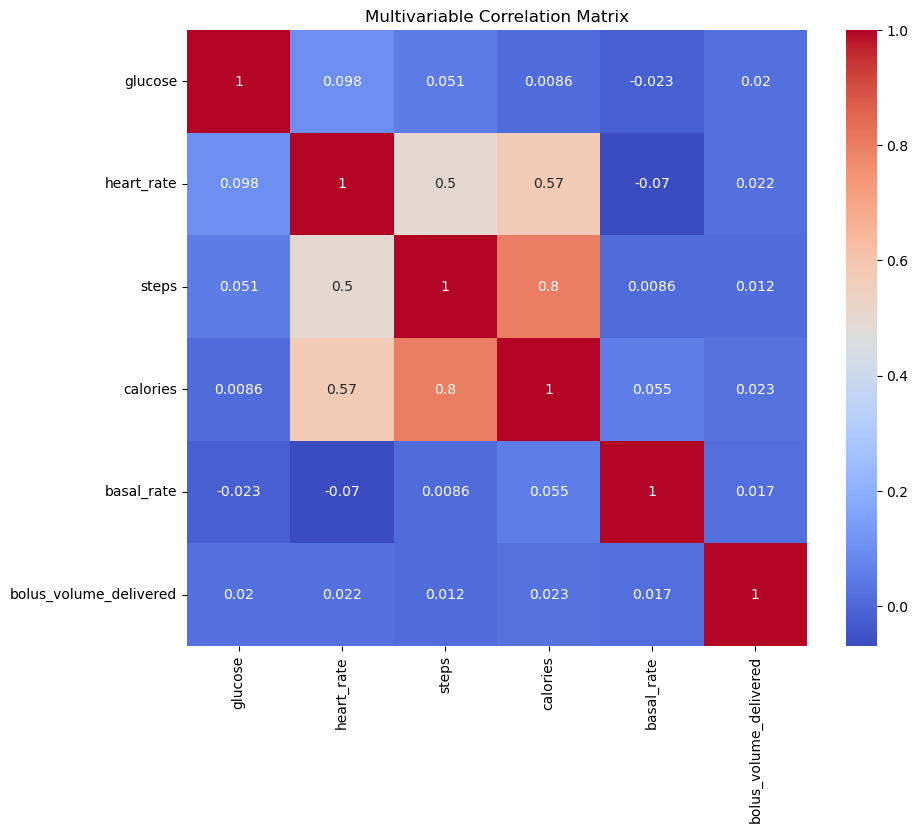

In [61]:
features = [
   'glucose',
   'heart_rate',
   'steps',
   'calories',
   'basal_rate',
   'bolus_volume_delivered'
]


corr = df[features].corr()


plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Multivariable Correlation Matrix")
plt.show()

### Insight
The multivariable correlation analysis revealed strong relationships between physical activity biomarkers such as steps and calories burned, while glucose showed weak direct correlation with individual biomarkers, including insulin delivery. These findings suggest that glucose regulation is highly multifactorial and influenced by complex interactions among activity, metabolism, insulin response, and patient-specific physiological factors. The results support the need for personalized, multi-factor diabetes monitoring and predictive healthcare systems.

### 20. How Can Insulin Dosage Recommendations Be Improved Using Glucose Trends?
###  Markers Chosen
glucose,
glucose_change,
basal_rate,
bolus_volume_delivered

### Why These Markers Were Chosen
Glucose trends provide important insight into how patients respond to insulin therapy over time.


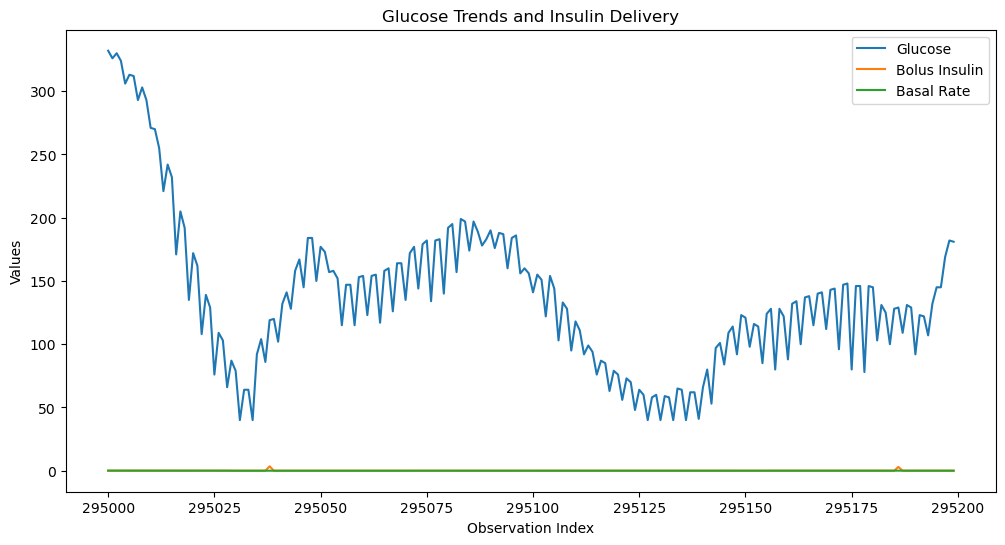

In [62]:
import matplotlib.pyplot as plt

# Calculate glucose trend/change
df['glucose_change'] = df['glucose'].diff()

# Select sample rows for visualization
sample = df.head(200)

plt.figure(figsize=(12,6))

plt.plot(sample['glucose'],
         label='Glucose')

plt.plot(sample['bolus_volume_delivered'],
         label='Bolus Insulin')

plt.plot(sample['basal_rate'],
         label='Basal Rate')

plt.title('Glucose Trends and Insulin Delivery')

plt.xlabel('Observation Index')
plt.ylabel('Values')

plt.legend()

plt.show()

# Correlation analysis
corr = df[['glucose',
           'glucose_change',
           'basal_rate',
           'bolus_volume_delivered']].corr()

#print(corr)

### Insight
The glucose trend analysis revealed substantial glucose variability despite relatively stable basal insulin delivery and limited bolus insulin events. Correlation analysis showed very weak direct relationships between insulin biomarkers and glucose behavior, suggesting that glucose regulation is highly multifactorial and patient-specific. These findings support the need for personalized insulin adjustment strategies, continuous glucose monitoring, and multi-factor predictive healthcare systems to improve diabetes management and reduce glucose instability.

### 21. How Can Prescriptive Analytics Help Prevent Hypoglycemia Events?
###  Markers Chosen
glucose,
glucose_change,
bolus_volume_delivered,
basal_rate,
carb_input,
heart_rate

### Why These Markers Were Chosen
Hypoglycemia occurs when blood glucose drops below normal levels, often due to:5.55

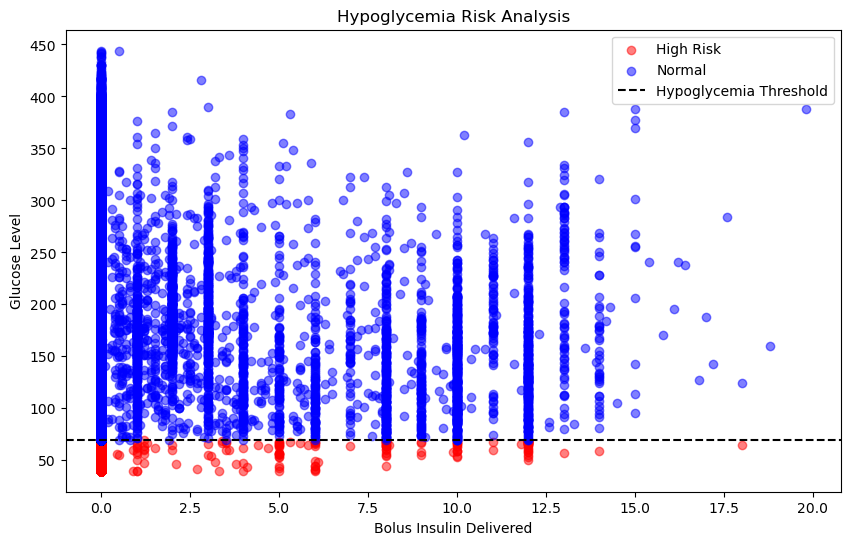

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Create glucose change
df['glucose_change'] = df['glucose'].diff()

# Define hypoglycemia risk
df['hypo_risk'] = np.where(df['glucose'] < 70,
                           'High Risk',
                           'Normal')

# Plot
plt.figure(figsize=(10,6))

colors = {'High Risk':'red',
          'Normal':'blue'}

for risk in colors:
    subset = df[df['hypo_risk'] == risk]

    plt.scatter(
        subset['bolus_volume_delivered'],
        subset['glucose'],
        c=colors[risk],
        label=risk,
        alpha=0.5
    )

plt.axhline(70,
            color='black',
            linestyle='--',
            label='Hypoglycemia Threshold')

plt.xlabel('Bolus Insulin Delivered')
plt.ylabel('Glucose Level')

plt.title('Hypoglycemia Risk Analysis')

plt.legend()

plt.show()

# Correlation
corr = df[['glucose',
           'glucose_change',
           'bolus_volume_delivered',
           'basal_rate',
           'carb_input',
           'heart_rate']].corr()

#print(corr)

### Insight
The hypoglycemia risk analysis revealed that low-glucose events occurred across a wide range of insulin doses, indicating that hypoglycemia cannot be explained by insulin delivery alone. Correlation analysis showed weak relationships between glucose and individual biomarkers, suggesting that glucose regulation is highly multifactorial and patient-specific. These findings highlight the importance of personalized insulin strategies, multi-biomarker predictive models, and continuous glucose monitoring systems to reduce hypoglycemia risk and improve diabetes management.

### 22. What Is the Delayed Effect of Insulin on Future Glucose Levels?
###  Markers Chosen
time,
glucose,
future_glucose,
bolus_volume_delivered,
basal_rate

### Why These Markers Were Chosen
Insulin does not immediately reduce glucose levels. After bolus insulin administration, glucose response may occur with a delay due to:

insulin absorption time
digestion rate
metabolic response
insulin sensitivity differences

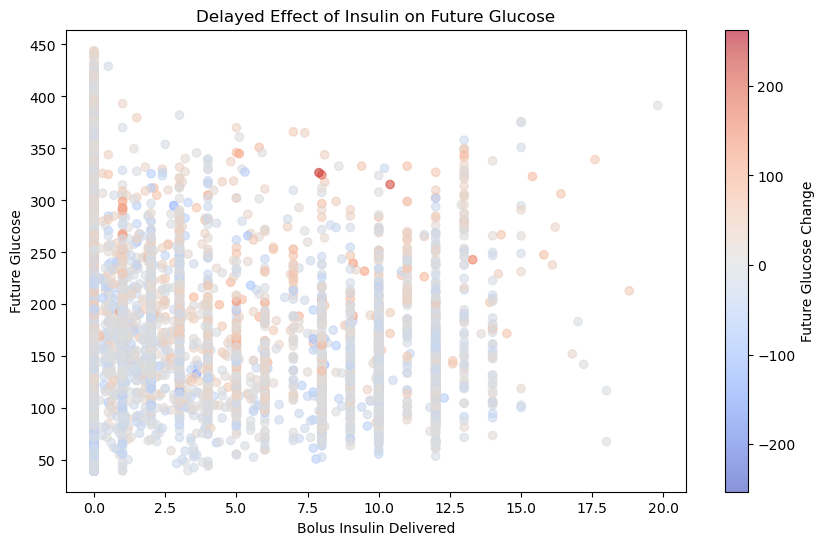

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Create future glucose (example: next 6 readings)
df['future_glucose'] = df['glucose'].shift(-6)

# Future glucose change
df['future_glucose_change'] = (
    df['future_glucose'] - df['glucose']
)

# Remove missing rows
lagged_df = df.dropna(subset=['future_glucose'])

# Plot
plt.figure(figsize=(10,6))

plt.scatter(
    lagged_df['bolus_volume_delivered'],
    lagged_df['future_glucose'],
    c=lagged_df['future_glucose_change'],
    cmap='coolwarm',
    alpha=0.6
)

plt.colorbar(label='Future Glucose Change')

plt.xlabel('Bolus Insulin Delivered')
plt.ylabel('Future Glucose')

plt.title('Delayed Effect of Insulin on Future Glucose')

plt.show()

# Correlation analysis
corr = lagged_df[[
    'bolus_volume_delivered',
    'basal_rate',
    'glucose',
    'future_glucose'
]].corr()

#print(corr)

### Insight
The event-based glucose response analysis revealed significant variability in glucose behavior following bolus insulin administration. While some patients experienced effective glucose reduction, others remained hyperglycemic despite higher insulin doses, suggesting possible insulin resistance or delayed insulin response. Additionally, extreme glucose reductions observed in certain patients may indicate hypoglycemia risk. These findings highlight the importance of personalized insulin dosing strategies and multi-factor predictive diabetes management systems.

### 23. Which Demographic Groups Show Higher Glucose Risk?
###  Markers Chosen
Gender,
Race,
glucose

### Why These Markers Were Chosen
Different demographic groups may show different glucose patterns due to lifestyle and genetic factors.

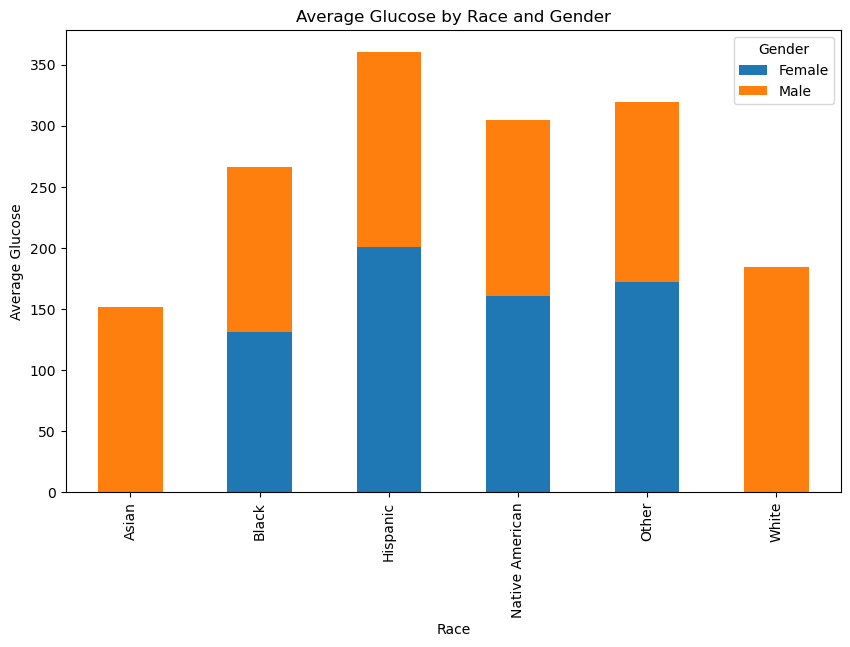

In [65]:
grouped = df.groupby(['Race','Gender'])['glucose'].mean().unstack()

grouped.plot(kind='bar', stacked=True, figsize=(10,6))

plt.ylabel('Average Glucose')
plt.title('Average Glucose by Race and Gender')

plt.show()

### Insight
The demographic glucose analysis revealed noticeable variation in average glucose levels across race and gender groups, with Hispanic and Native American populations showing relatively higher glucose values. Male patients also demonstrated slightly elevated glucose levels in several demographic categories. These findings suggest that diabetes risk and glucose regulation may vary across demographic groups, highlighting the importance of personalized healthcare strategies, targeted prevention programs, and demographic-aware diabetes management approaches.

### 24. Should calorie expenditure be used to recommend insulin dosage changes?¶
### Markers Chosen
* calories
* glucose
* bolus_volume_delivered
### Why?
Higher calorie burn can lower glucose faster. Medical Influence Exercise-induced glucose reduction may require insulin adjustment to avoid hypoglycemia.

                        calories   glucose  bolus_volume_delivered
calories                1.000000  0.008568                0.023381
glucose                 0.008568  1.000000                0.020113
bolus_volume_delivered  0.023381  0.020113                1.000000


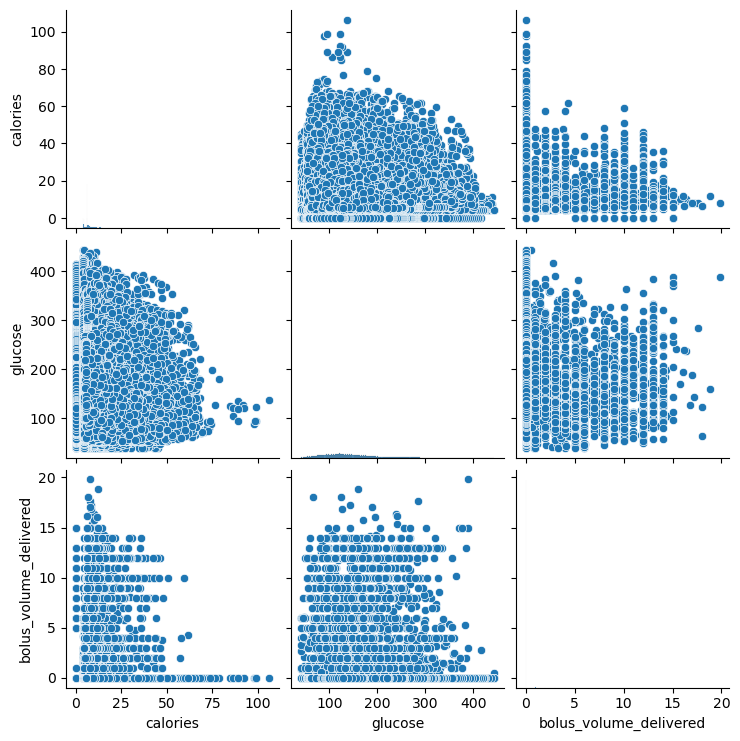

In [66]:
corr = df[['calories', 'glucose', 'bolus_volume_delivered']].corr()
print(corr)


sns.pairplot(df[['calories', 'glucose', 'bolus_volume_delivered']])
plt.show()

### Insight: 
Our analysis found that calorie expenditure alone had almost no correlation with glucose levels or insulin delivery. This suggests that insulin recommendations should not rely solely on calories burned. Instead, diabetes management may require combining multiple physiological indicators such as glucose trends, insulin dosage, activity intensity, and heart rate for more personalized treatment decisions.

### Comparing calories burned with future glucose values. To see if we can find any correlation.

                calories  future_glucose
calories        1.000000        0.018538
future_glucose  0.018538        1.000000


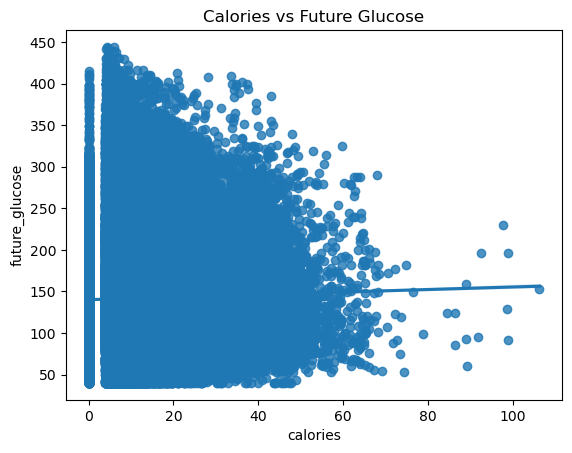

In [67]:
# Sort by time
df = df.sort_values('time')

# Future glucose after 1 hour
df['future_glucose'] = df['glucose'].shift(-12)  # if data every 5 mins

corr = df[['calories', 'future_glucose']].corr()
print(corr)

sns.regplot(data=df,
            x='calories',
            y='future_glucose')

plt.title("Calories vs Future Glucose")
plt.show()

### Checking if Steps + heart rate together may better represent true exertion.

In [68]:
exercise_score = df['steps'] * df['heart_rate']

df['exercise_score'] = exercise_score

corr = df[['exercise_score', 'glucose']].corr()
print(corr)

                exercise_score   glucose
exercise_score        1.000000  0.045342
glucose               0.045342  1.000000


#### Insight:
* We explored whether physical activity and calorie expenditure could guide glucose management and insulin recommendations. Correlation analysis showed a moderate positive relationship between daily steps and glucose variability (r=0.505), suggesting that increased activity may lead to larger glucose fluctuations rather than stabilization.
* In contrast, calorie expenditure showed extremely weak correlations with both glucose levels (r=0.0086) and future glucose trends (r=0.018), indicating that calories burned alone are not reliable predictors of glucose response.
*  A combined exercise intensity metric using steps and heart rate also demonstrated only a weak association with glucose (r=0.045).
*  These findings suggest that diabetes management cannot rely on single activity-related markers alone. Instead, effective prescriptive recommendations should integrate multiple physiological variables such as glucose history, insulin delivery, heart rate, meal intake, and activity intensity to support personalized treatment strategies.

### 25. Can elevated heart rate predict upcoming glucose abnormalities?
### Markers Chosen
heart_rate
glucose
### Why?

### Heart rate may reflect:

* Stress
* Exercise
* Physiological responses to hypoglycemia

### Medical Influence

Rapid heart rate is often associated with hypoglycemic episodes.

            heart_rate   glucose
heart_rate    1.000000  0.098378
glucose       0.098378  1.000000


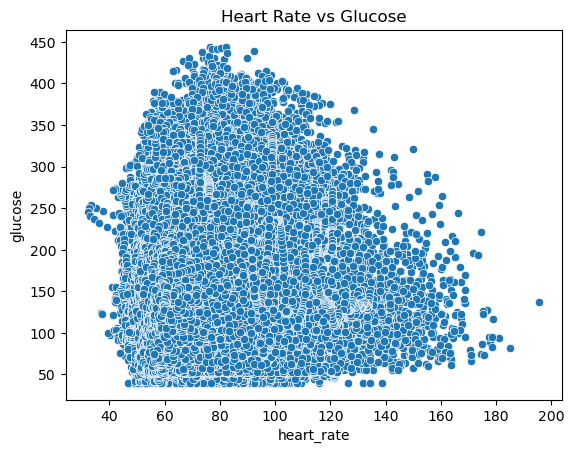

In [69]:
corr = df[['heart_rate', 'glucose']].corr()
print(corr)

sns.scatterplot(data=df, x='heart_rate', y='glucose')
plt.title("Heart Rate vs Glucose")
plt.show()

#### Insight:
Correlation analysis between heart rate and glucose levels revealed a weak positive relationship (r=0.098).

r=0.098378

The scatterplot demonstrated substantial variability in glucose values across all heart rate ranges, indicating the absence of a strong linear association.
Heart rate is affected by numerous physiological and environmental factors beyond glucose regulation, including exercise, stress, and autonomic nervous system activity.

Although elevated heart rate may occur during hypoglycemic events, it does not appear to consistently predict glucose abnormalities on its own.Diabetes monitoring systems should avoid relying solely on heart rate for glucose prediction or alert generation.

Instead, heart rate should be integrated with:

glucose trends,
insulin delivery,
physical activity,
and nutritional intake
to improve predictive accuracy and personalized intervention strategies.

### 26. Should basal insulin rates be dynamically adjusted during nighttime glucose instability?
#### Markers Chosen
glucose
basal_rate
time
#### Why?
Basal insulin controls glucose continuously.
Nighttime instability may indicate inadequate basal dosing.
Medical Influence

Incorrect nighttime basal rates can cause:

* Nocturnal hypoglycemia
* Morning hyperglycemia

             glucose  basal_rate
glucose     1.000000   -0.063149
basal_rate -0.063149    1.000000


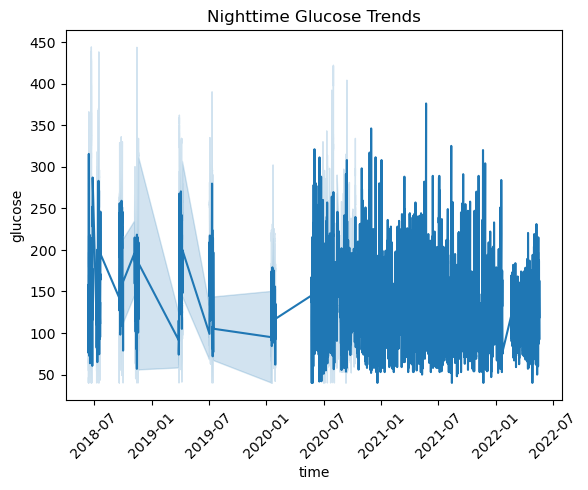

In [70]:
# Extract nighttime records
night_df = df[(df['time'].dt.hour >= 0) & (df['time'].dt.hour <= 6)]

corr = night_df[['glucose', 'basal_rate']].corr()
print(corr)

sns.lineplot(data=night_df, x='time', y='glucose')
plt.title("Nighttime Glucose Trends")
plt.xticks(rotation=45)
plt.show()

#### Insight: 
Correlation analysis between basal insulin rate and glucose levels showed a weak negative relationship (r=−0.063).

r=−0.063149

The nighttime glucose trend visualization demonstrated persistent glucose fluctuations over time, including repeated hyperglycemic and hypoglycemic patterns despite basal insulin delivery.

Although basal insulin is intended to maintain stable overnight glucose levels, nighttime glucose regulation appears to be influenced by multiple physiological and behavioral factors beyond basal insulin alone.

The observed variability suggests that fixed basal insulin dosing may not adequately adapt to changing metabolic conditions during sleep.
Patients experiencing nighttime glucose instability may benefit from:

dynamic basal insulin adjustment,
continuous glucose monitoring,
and personalized insulin delivery systems capable of adapting to real-time glucose fluctuations.

## 27. Should patients increase physical activity after high-carb meals to reduce glucose spikes?
### Columns Chosen:
carb_input
steps
glucose
### Why These Markers Are Important:

High carbohydrate intake can rapidly increase blood glucose levels. Physical activity, especially walking after meals, helps muscles utilize glucose more effectively. This analysis helps determine whether increasing movement after meals could improve glucose control.

### Prescriptive Goal:

Recommend post-meal walking or exercise routines when carbohydrate intake is high.

In [71]:
import pandas as pd

# High-carb meals
high_carb = df[df['carb_input'] > 40]

# Compare average glucose for active vs inactive periods
active = high_carb[high_carb['steps'] > 100]
inactive = high_carb[high_carb['steps'] <= 100]

print("Average glucose (active):", active['glucose'].mean())
print("Average glucose (inactive):", inactive['glucose'].mean())

Average glucose (active): 182.54571428571427
Average glucose (inactive): 147.5003125


#### Insight:
The analysis compared glucose levels between active and inactive patients after high-carbohydrate meals. Surprisingly, physically active patients showed higher average glucose levels (182.55 mg/dL) than inactive patients (147.50 mg/dL). This may indicate that patients exercised in response to already elevated glucose levels rather than exercise causing higher glucose. The findings suggest that physical activity alone may not immediately control post-meal glucose spikes, and additional factors such as insulin timing, meal composition, and delayed exercise effects should be considered in diabetes management.

## 28. Should elevated heart rate be used as an early warning sign for glucose instability?
### Columns Chosen:
* heart_rate
* glucose
### Why These Markers Are Important:

Abnormal glucose levels can place stress on the body, causing increased heart rate. Monitoring heart rate patterns may help identify periods of glucose instability earlier.

### Prescriptive Goal:

Recommend alert systems or proactive glucose checks during elevated heart rate episodes.

In [72]:
# Elevated heart rate threshold
high_hr = df[df['heart_rate'] > 100]

print("Average glucose during elevated heart rate:")
print(high_hr['glucose'].mean())

# Compare with normal heart rate
normal_hr = df[df['heart_rate'] <= 100]

print("Average glucose during normal heart rate:")
print(normal_hr['glucose'].mean())

Average glucose during elevated heart rate:
142.607100792752
Average glucose during normal heart rate:
141.32290493353568


#### Insight:
The results show only a very small difference in glucose levels between periods of elevated heart rate and normal heart rate.

Elevated heart rate glucose average: 142.61 mg/dL
Normal heart rate glucose average: 141.32 mg/dL

Based on this analysis, elevated heart rate should not be used independently as an early warning indicator for glucose instability.

Instead, heart rate may be more useful when combined with other markers such as:

Physical activity (steps)
Sleep quality
Insulin delivery
Continuous glucose monitoring trends

A multi-variable monitoring system would likely provide more accurate predictions of glucose fluctuations.